# Classificação de Crises Epilépticas via EEG
## Projeto de Otimização Não Linear — Regressão Logística + Gradiente Descendente

**Integrantes:** Bruno Marques Rodrigues, Gabrielly Silva Batista, Josué Caleb Avelino dos Santos, Vitória Emanuele de Sousa Silva.

Este notebook implementa, de forma comentada, um problema de **otimização não linear sem restrições** aplicado ao **aprendizado supervisionado**, mais especificamente uma **classificação binária** de sinais de EEG em duas classes:

- **Classe 1:** crise epiléptica
- **Classe 0:** ausência de crise

A ideia central é modelar a tarefa por meio da **Regressão Logística**, cuja função objetivo é a **Entropia Cruzada (Log-Loss)**. O treinamento será feito com **Gradiente Descendente**, destacando o aspecto de otimização do projeto.

## 0. Objetivos do notebook

Neste notebook, vamos:

1. carregar o conjunto de dados;
2. inspecionar o formato dos sinais de EEG;
3. pré-processar os dados;
4. formular o problema matematicamente;
5. implementar a Regressão Logística **do zero**;
6. treinar o modelo via **Gradiente Descendente**;
7. avaliar os resultados;
8. comparar, opcionalmente, com a implementação do `scikit-learn`.

> **Observação importante:** o foco principal do projeto não é apenas classificar bem, mas mostrar claramente a **formulação de otimização**, o cálculo do gradiente, o processo iterativo e os resultados obtidos.

## 1. Bibliotecas
Se alguma biblioteca não estiver instalada, rode no terminal do VS Code:

```bash
pip install numpy matplotlib scikit-learn jupyter
```

In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    roc_curve,
    recall_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 2. Definir o caminho do dataset

Altere a variável `path_base` para a pasta onde estão os arquivos:

- `eeg-seizure_train.npz`
- `eeg-seizure_test.npz`

In [2]:
path = kagglehub.dataset_download("adibadea/chbmitseizuredataset")

print("Dataset baixado em:", path)
print("Arquivos:", os.listdir(path))

Dataset baixado em: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Arquivos: ['eeg-seizure_train.npz', 'eeg-predictive_train.npz', 'eeg-seizure_test.npz', 'eeg-predictive_val_balanced.npz', 'eeg-predictive_val.npz', 'eeg-seizure_val_balanced.npz', 'eeg-seizure_val.npz']


## 3. Verificar os arquivos e carregar os dados

Esperamos encontrar, na pasta do dataset, os arquivos:

- `eeg-seizure_train.npz`
- `eeg-seizure_test.npz`

A célula abaixo carrega os dados e mostra seus formatos.

In [3]:
# Baixar/obter o caminho do dataset
path = kagglehub.dataset_download("adibadea/chbmitseizuredataset")
print("Dataset baixado em:", path)

# Verificar a estrutura da pasta
arquivos = os.listdir(path)
print("Conteúdo da pasta:", arquivos)

# Definir automaticamente o caminho base correto
if "eeg-seizure_train.npz" in arquivos and "eeg-seizure_test.npz" in arquivos:
    path_base = path
elif "dataset" in arquivos:
    path_base = os.path.join(path, "dataset")
else:
    raise FileNotFoundError(
        f"Não encontrei os arquivos esperados em {path}. Conteúdo encontrado: {arquivos}"
    )

print("Caminho final usado:", path_base)

arquivo_treino = os.path.join(path_base, "eeg-seizure_train.npz")
arquivo_teste = os.path.join(path_base, "eeg-seizure_test.npz")

print("Arquivo de treino:", arquivo_treino)
print("Arquivo de teste :", arquivo_teste)

if not os.path.exists(arquivo_treino):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_treino}")

if not os.path.exists(arquivo_teste):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_teste}")

dados_treino = np.load(arquivo_treino)
dados_teste = np.load(arquivo_teste)

print("\nChaves no treino:", dados_treino.files)
print("Chaves no teste :", dados_teste.files)


Dataset baixado em: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Conteúdo da pasta: ['eeg-seizure_train.npz', 'eeg-predictive_train.npz', 'eeg-seizure_test.npz', 'eeg-predictive_val_balanced.npz', 'eeg-predictive_val.npz', 'eeg-seizure_val_balanced.npz', 'eeg-seizure_val.npz']
Caminho final usado: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8
Arquivo de treino: /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8/eeg-seizure_train.npz
Arquivo de teste : /home/gabriellybatista/.cache/kagglehub/datasets/adibadea/chbmitseizuredataset/versions/8/eeg-seizure_test.npz

Chaves no treino: ['train_signals', 'train_labels']
Chaves no teste : ['test_signals']


## 4. Separar, Explorar e Balancear os Dados

Como o arquivo de teste não possui rótulos, vamos usar apenas:

- `train_signals`
- `train_labels`

Depois criaremos nossa própria divisão treino/teste.

In [4]:
X = dados_treino["train_signals"]
y = dados_treino["train_labels"]

print("Shape original de X:", X.shape)
print("Shape original de y:", y.shape)

Shape original de X: (37666, 23, 256)
Shape original de y: (37666,)


### 4.1 Exploração Visual dos Dados

Antes de pré-processar, visualizamos a distribuição das classes e um segmento
de sinal de cada classe. Crises epilépticas costumam apresentar amplitudes muito
maiores e padrões de disparo distintos do sinal normal.

Classe 1 (Crise) : 8074 amostras (21.4%)
Classe 0 (Normal): 29592 amostras (78.6%)


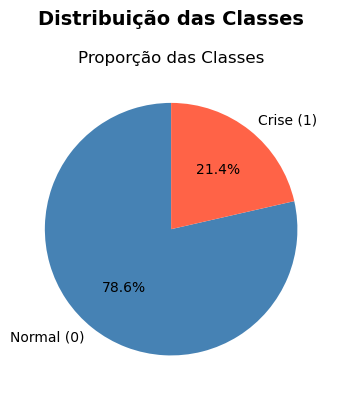

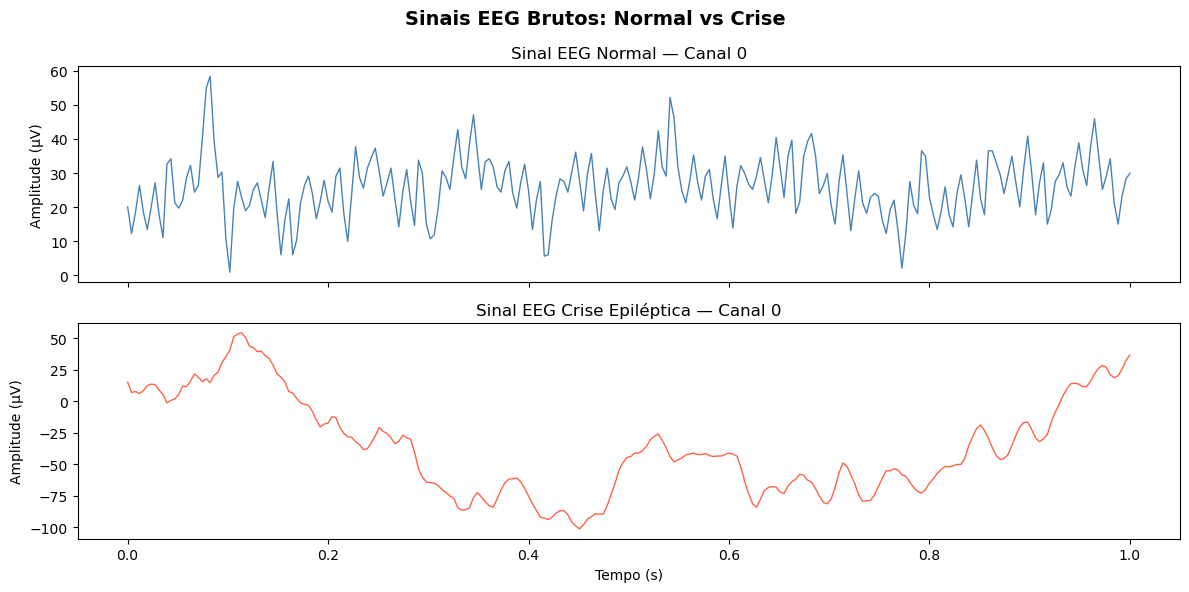

In [5]:
n_crise  = int((y == 1).sum()) # total de segmentos com crise
n_normal = int((y == 0).sum()) # total de segmentos normais
total    = len(y)
print(f'Classe 1 (Crise) : {n_crise} amostras ({100*n_crise/total:.1f}%)')
print(f'Classe 0 (Normal): {n_normal} amostras ({100*n_normal/total:.1f}%)')

# ── Gráfico de distribuição das classes ──────────────────────
# Gráfico de pizza para melhor visualização da distribuição dos dados
fig, ax = plt.subplots(figsize=(11, 4))
ax.pie([n_normal, n_crise], labels=['Normal (0)', 'Crise (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
ax.set_title('Proporção das Classes')
plt.suptitle('Distribuição das Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Visualização dos sinais EEG brutos ───────────────────────
# Pega o primeiro índice de cada classe para comparação visual
idx_normal = np.where(y == 0)[0][0]
idx_crise  = np.where(y == 1)[0][0]

# Eixo de tempo: 256 pontos em 1 segundo = frequência de amostragem 256 Hz
t = np.linspace(0, 1, X.shape[2])
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(t, X[idx_normal, 0, :], color='steelblue', linewidth=1)
axes[0].set_title('Sinal EEG Normal — Canal 0')
axes[0].set_ylabel('Amplitude (μV)')
axes[1].plot(t, X[idx_crise,  0, :], color='tomato',    linewidth=1)
axes[1].set_title('Sinal EEG Crise Epiléptica — Canal 0')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_xlabel('Tempo (s)')
plt.suptitle('Sinais EEG Brutos: Normal vs Crise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Balanceamento das Classes

O dataset tem **78% Normal vs 22% Crise**. Sem balancear, o modelo pode atingir
~78% de acurácia simplesmente prevendo sempre 'Normal'. Aplicamos **undersampling**
para igualar as classes na proporção 1:1.

In [6]:
idx1  = np.where(y == 1)[0]   # índices das amostras de crise
idx0  = np.where(y == 0)[0]   # índices das amostras normais
n_min = min(len(idx1), len(idx0))  # tamanho da menor classe

np.random.seed(42)
# Sorteia aleatoriamente n_min amostras de cada classe (sem reposição)
idx_bal = np.concatenate([
    np.random.choice(idx1, n_min, replace=False),
    np.random.choice(idx0, n_min, replace=False)
])

# Embaralha para evitar que o modelo veja padrões na ordem dos dados
np.random.shuffle(idx_bal)

X = X[idx_bal]
y = y[idx_bal]

## 5. Pré-processamento
### 5.1 Garantir que `y` fique em vetor

In [7]:
# Garantir que y fique em formato vetorial
y = y.reshape(-1)
print("Shape de y após reshape:", y.shape)

Shape de y após reshape: (16148,)


### 5.2 Extração de Features Estatísticas dos Sinais EEG

Em vez de usar o sinal bruto achatado (flatten), extraímos features estatísticas de cada canal. Isso é necessário porque a diferença entre crises e sinais normais está na **amplitude e variabilidade** do sinal, não nos valores brutos ponto a ponto.

Para cada um dos **23 canais** calculamos **13 features**:

#### Features estatísticas (8)

| Feature | O que captura |
|---|---|
| Média | Nível médio do sinal |
| Desvio padrão | Variabilidade geral |
| Valor absoluto médio | Energia média |
| Mínimo | Amplitude mínima |
| Máximo | Amplitude máxima |
| Pico-a-pico | Máximo − Mínimo |
| Variância | Dispersão quadrática do sinal |
| Energia | Potência média do sinal (Σx²/n) |


#### Features espectrais via FFT (5)

Calculadas aplicando a Transformada Rápida de Fourier (FFT) e extraindo a potência média em cada banda de frequência clinicamente relevante para EEG:

| Feature | Banda (Hz) | O que captura |
|---|---|---|
| Delta | 0.5 – 4 Hz | Sono profundo, coma |
| Theta | 4 – 8 Hz | Sonolência, meditação |
| Alpha | 8 – 13 Hz | Relaxamento acordado |
| Beta | 13 – 30 Hz | Atenção, cognição ativa |
| Gamma | 30 – 80 Hz | Processamento de alta frequência, comum em crises |

**23 canais × 13 features = 299 features** por amostra.

In [8]:
# Cada operação é calculada no eixo temporal (axis=2), resultando em shape (n, 23) por feature.
# O hstack concatena tudo em (n, 299).
def extrair_features(X):
    # Transforma (n, 23, 256) -> (n,299)
    # 13 features por canal x 23 canais  = 299 features

    media  =      X.mean(axis=2)
    desvio =      X.std(axis=2)
    abs_media =   np.abs(X).mean(axis=2)
    minimo =      X.min(axis=2)
    maximo =      X.max(axis=2)
    pico_a_pico = maximo - minimo # range de sinal 
    variancia =   X.var(axis=2)
    energia =     (X**2).mean(axis=2)

    # ── Features espectrais via FFT (5 × 23 = 115) ───────────────
    # X: (n, 23, 256)  →  fft_mag: (n, 23, 129)
    fft_mag = np.abs(np.fft.rfft(X, axis=2))
    freqs   = np.fft.rfftfreq(256, d=1/256)  # 0 a 128 Hz

    delta = fft_mag[:, :, (freqs >= 0.5) & (freqs <  4)].mean(axis=2)
    theta = fft_mag[:, :, (freqs >=  4)  & (freqs <  8)].mean(axis=2)
    alpha = fft_mag[:, :, (freqs >=  8)  & (freqs < 13)].mean(axis=2)
    beta  = fft_mag[:, :, (freqs >= 13)  & (freqs < 30)].mean(axis=2)
    gamma = fft_mag[:, :, (freqs >= 30)  & (freqs < 80)].mean(axis=2)

    return np.hstack([media, desvio, abs_media, minimo, maximo, pico_a_pico, variancia, energia, delta, theta, alpha, beta, gamma])

X = extrair_features(X)
print("Shape de X após extração de features:", X.shape)

Shape de X após extração de features: (16148, 299)


### 5.2.1 Análise de Correlação das Features com o Target

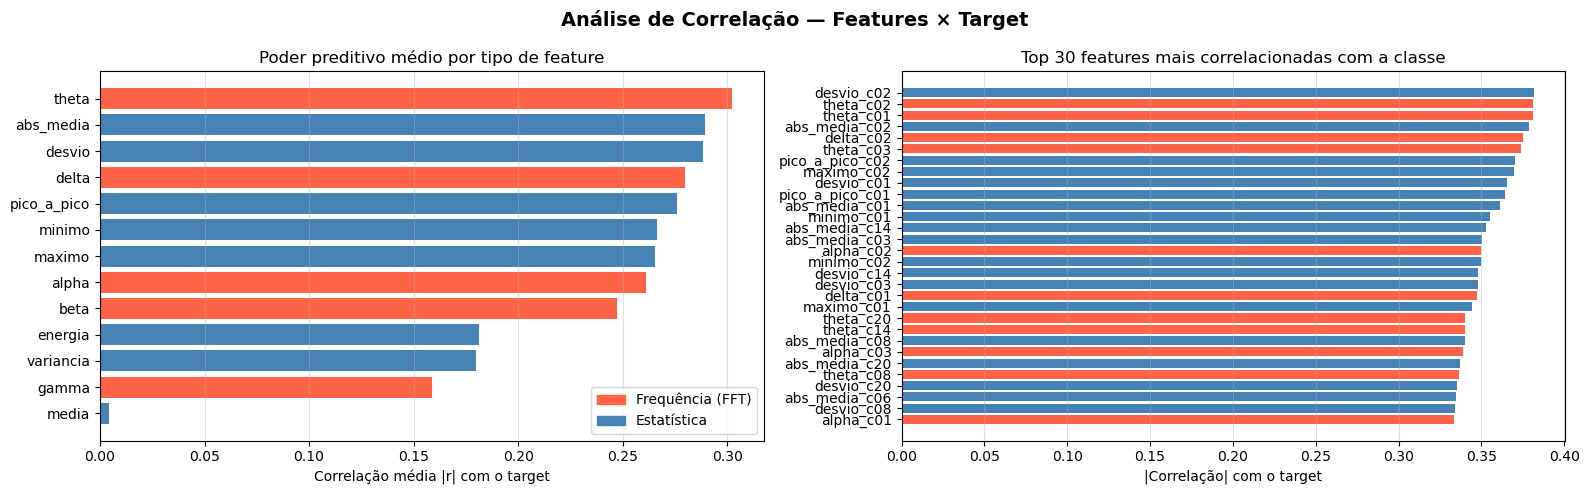


Tipo             Corr. média    Corr. máx  Grupo
───────────────────────────────────────────────────────
theta                 0.3025       0.3810  ← FFT
abs_media             0.2895       0.3789  estatística
desvio                0.2883       0.3816  estatística
delta                 0.2798       0.3751  ← FFT
pico_a_pico           0.2761       0.3702  estatística
minimo                0.2666       0.3554  estatística
maximo                0.2655       0.3694  estatística
alpha                 0.2612       0.3495  ← FFT
beta                  0.2475       0.3042  ← FFT
energia               0.1813       0.2359  estatística
variancia             0.1798       0.2345  estatística
gamma                 0.1587       0.2423  ← FFT
media                 0.0041       0.0118  estatística


In [9]:
# ── Nomes das 299 features (mesma ordem do extrair_features) ───────
n_canais    = 23
tipos_stat  = ['media', 'desvio', 'abs_media', 'minimo', 'maximo',
               'pico_a_pico', 'variancia', 'energia']
tipos_freq  = ['delta', 'theta', 'alpha', 'beta', 'gamma']
todos_tipos = tipos_stat + tipos_freq

nomes = [f"{tipo}_c{c:02d}" for tipo in todos_tipos for c in range(n_canais)]
# 13 tipos × 23 canais = 299 features

# ── Correlação |r| de cada feature com y ──────────────────────────
df_feat  = pd.DataFrame(X, columns=nomes)
corr_abs = df_feat.corrwith(pd.Series(y, name='target')).abs()

# ── Correlação média por tipo ──────────────────────────────────────
media_por_tipo = {
    tipo: corr_abs[[f for f in nomes if f.startswith(tipo + '_')]].mean()
    for tipo in todos_tipos
}
tipos_ord = sorted(media_por_tipo, key=media_por_tipo.get, reverse=True)

# ─── GRÁFICO 1 e 2 lado a lado ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1 — poder preditivo médio por tipo
cores = ['tomato' if t in tipos_freq else 'steelblue' for t in tipos_ord[::-1]]
axes[0].barh(
    tipos_ord[::-1],
    [media_por_tipo[t] for t in tipos_ord[::-1]],
    color=cores
)
axes[0].set_xlabel('Correlação média |r| com o target')
axes[0].set_title('Poder preditivo médio por tipo de feature')
axes[0].legend(handles=[
    Patch(color='tomato',    label='Frequência (FFT)'),
    Patch(color='steelblue', label='Estatística'),
])
axes[0].grid(axis='x', alpha=0.4)

# Gráfico 2 — top 30 features individuais
top30 = corr_abs.sort_values(ascending=False).head(30)
cores30 = [
    'tomato' if any(t + '_' in f for t in tipos_freq) else 'steelblue'
    for f in top30.index[::-1]
]
axes[1].barh(top30.index[::-1], top30.values[::-1], color=cores30)
axes[1].set_xlabel('|Correlação| com o target')
axes[1].set_title('Top 30 features mais correlacionadas com a classe')
axes[1].grid(axis='x', alpha=0.4)

plt.suptitle('Análise de Correlação — Features × Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── TABELA RESUMO ─────────────────────────────────────────────────
print(f"\n{'Tipo':<15} {'Corr. média':>12} {'Corr. máx':>12}  {'Grupo'}")
print("─" * 55)
for tipo in tipos_ord:
    cols  = [f for f in nomes if f.startswith(tipo + '_')]
    media = corr_abs[cols].mean()
    maxi  = corr_abs[cols].max()
    grupo = "← FFT" if tipo in tipos_freq else "estatística"
    print(f"{tipo:<15} {media:>12.4f} {maxi:>12.4f}  {grupo}")

### 5.3 Dividir em treino e teste

In [10]:
# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nShapes após train_test_split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Shapes após train_test_split:
X_train: (12918, 299)
X_test : (3230, 299)
y_train: (12918,)
y_test : (3230,)


### 5.4 Normalizar com Z-score
#### Por que isso é importante?
Sem normalização, algumas variáveis podem ter escalas muito maiores do que outras, deformando a superfície da função objetivo e dificultando a convergência do método iterativo.

In [11]:
# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nShapes após normalização:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

# Verificação de consistência
assert X_train.shape[0] == y_train.shape[0], "X_train e y_train têm tamanhos incompatíveis"
assert X_test.shape[0] == y_test.shape[0], "X_test e y_test têm tamanhos incompatíveis"

print("\nVerificação concluída: dimensões compatíveis.")


Shapes após normalização:
X_train: (12918, 299)
X_test : (3230, 299)
y_train: (12918,)
y_test : (3230,)

Verificação concluída: dimensões compatíveis.


## 6. Formulação matemática

A regressão logística utiliza a função sigmoide:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

O modelo é definido como:

$$
\hat{y} = \sigma(Xw + b)
$$

A função de custo (Log-Loss) é dada por:

$$
J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]
$$

A atualização dos parâmetros pelo **Gradiente Descendente** é:

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}
$$

$$
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

Para o **Gradiente Descendente Estocástico (SGD)** que em vez de calcular o gradiente sobre todas as $m$ amostras, atualiza os parâmetros usando **uma amostra $i$ por vez**:

$$
\hat{y}^{(i)} = \sigma(\mathbf{w}^T \mathbf{x}^{(i)} + b)
$$

A regra de atualização para cada amostra $i$ é:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \cdot (\hat{y}^{(i)} - y^{(i)}) \cdot \mathbf{x}^{(i)}
$$

$$
b \leftarrow b - \alpha \cdot (\hat{y}^{(i)} - y^{(i)})
$$

#### Método de Newton

O Método de Newton utiliza a **segunda derivada** (Hessiana) da função objetivo para calcular o tamanho ideal do passo em cada
direção, resultando em convergência quadrática:

$$w^{(t+1)} = w^{(t)} - H^{-1}(w^{(t)}) \cdot \nabla J(w^{(t)})$$

A Hessiana da Log-Loss é:

$$H = \frac{1}{m} X^T \cdot \text{diag}(\hat{y}(1-\hat{y})) \cdot X$$

**Comparação com o GD:**

| | GD Batch | SGD | Newton |
|---|---|---|---|
| Derivadas usadas | 1ª | 1ª | 1ª e 2ª |
| Iterações típicas | ~1000 | ~50 épocas | ~50 |
| Custo por iteração | baixo | muito baixo | alto (O(n³)) |
| Convergência | linear | ruidosa | quadrática |

## 7. Implementação da regressão logística do zero

In [12]:
def sigmoid(z):
    z = np.clip(z, -500, 500) # np.clip evita overflow no esp() para valores extremos de z
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    eps = 1e-10
    y_hat = np.clip(y_hat, eps, 1 - eps)

    cost = -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return cost

def compute_gradients(X, y, w, b):
    m = X.shape[0]
    z = X @ w + b
    y_hat = sigmoid(z)

    dw = (1 / m) * (X.T @ (y_hat - y))
    db = (1 / m) * np.sum(y_hat - y)

    return dw, db

# Gradiente Descendente Batch (GD)
# A cada iteração, o gradiente é calculado sobre TODAS as m amostras de treinamento de uma só vez.
# Isso garante convergência suave e determinística em direção ao mínimo global (pois a Log-Loss é convexa).
def gradient_descent_gd(X, y, learning_rate=0.1, epochs=3000, tol=1e-2, verbose=True):
    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0.0
    cost_history_gd = []
    grad_norm_history_gd = []

    for epoch in range(epochs):
        dw, db = compute_gradients(X, y, w, b)

        # Norma do gradiente completo (pesos + viés)
        grad_norm = np.sqrt(np.sum(dw**2) + db**2)
        grad_norm_history_gd.append(grad_norm)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        cost = compute_cost(X, y, w, b)
        cost_history_gd.append(cost)

        # Critério de parada por convergência
        if grad_norm < tol:
            if verbose:
                print(f"Convergência atingida na época {epoch} | ‖∇J‖ = {grad_norm:.2e}")
            break

        if verbose and (epoch % 100 == 0 or epoch == epochs - 1):
            print(f"GD Época {epoch:4d} | custo = {cost:.6f} | ‖∇J‖ = {grad_norm:.2e}")

    return w, b, cost_history_gd, grad_norm_history_gd

# Gradiente Descendente Estocástico (SGD)
# Minimiza a Log-Loss via Gradiente Descendente Estocástico.
# Diferença do GD batch: em vez de calcular o gradiente sobre todas as amostras, o SGD usa UMA amostra aleatória por atualização.
# A cada época, as amostras são embaralhadas (permutation) para garantir que o modelo não aprenda padrões de ordem nos dados.
def gradient_descent_sgd(X, y, learning_rate=0.001, epochs=50, tol=1e-4, verbose=True):
    m, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0
    cost_history_sgd = []

    for epoch in range(epochs):
        # Embaralha os índices a cada época (fundamental no SGD)
        indices = np.random.permutation(m)
        custos = []
        for i in indices:
            xi = X[i]; yi = y[i]
            yi_hat = sigmoid(xi @ w + b)
            eps = 1e-15
            yi_hat = np.clip(yi_hat, eps, 1 - eps)
            erro = yi_hat - yi

            # Atualização dos parâmetros com o gradiente da amostra i
            w -= learning_rate * erro * xi
            b -= learning_rate * erro

            custos.append(-(yi*np.log(yi_hat) + (1-yi)*np.log(1-yi_hat)))

        # Custo médio da época (média sobre todas as amostras)
        custo_medio = np.mean(custos)
        cost_history_sgd.append(custo_medio)

        # Critério de convergência: variação do custo entre épocas
        if epoch > 0:
            delta = abs(cost_history_sgd[-2] - cost_history_sgd[-1])
            if delta < tol:
                if verbose:
                    print(f"Convergência atingida na época {epoch} | Δcusto = {delta:.2e}")
                break

        # Print de progresso
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            delta_str = f" | Δcusto = {abs(cost_history_sgd[-2] - cost_history_sgd[-1]):.2e}" if epoch > 0 else ""
            print(f"SGD Época {epoch:4d} | custo médio = {custo_medio:.6f}{delta_str}")
            
    return w, b, cost_history_sgd

def predict_proba(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def predict(X, w, b, threshold=0.5):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

# Matriz Hessiana da Log-Loss em relação a w.
# A Hessiana é a matriz de segundas derivadas parciais — ela descreve a curvatura da função objetivo em cada direção.
# Para a Log-Loss, é garantidamente positiva semi-definida, confirmando a convexidade da função.
# Fórmula: H = (1/m) * Xᵀ · diag(ŷ·(1−ŷ)) · X
def compute_hessian(X, y, w, b):
    m     = X.shape[0]
    y_hat = sigmoid(X @ w + b)
    
    # Pesos de curvatura: máximo em ŷ=0.5 (maior incerteza)
    S = y_hat * (1 - y_hat)
    
    # Hessiana: produto matricial ponderado
    H = (1/m) * (X.T * S) @ X
    return H

# Minimiza a Log-Loss via Método de Newton.
# Diferença do GD: em vez de usar apenas o gradiente (direção), usa também a Hessiana (curvatura) para calcular o tamanho ideal do passo em cada direção.
# Isso resulta em convergência muito mais rápida, tipicamente em poucas dezenas de iterações contra centenas/milhares do GD.
# Custo computacional: inverter a Hessiana é O(n³), o que pode ser proibitivo para n muito grande. Para n=299 features é viável.
#
# Parâmetros:
# X             : array (m, n) — features normalizadas
# y             : array (m,)   — rótulos
# learning_rate : float — α (geralmente 1.0 no Newton puro)
# epochs        : int   — número de iterações
#
# Retorna: w, b, cost_history
def newton_method(X, y, learning_rate=1.0, epochs=50, tol=1e-2, verbose=True):
    m, n         = X.shape
    w            = np.zeros(n)
    b            = 0.0
    cost_history = []

    for epoch in range(epochs):
        # Gradiente (primeira derivada)
        dw, db = compute_gradients(X, y, w, b)

        # Critério de convergência: mesma lógica do GD
        # No mínimo da função convexa, o gradiente tende a zero
        grad_norm = np.sqrt(np.sum(dw**2) + db**2)

        # Hessiana (segunda derivada)
        H = compute_hessian(X, y, w, b)

        # Regularização numérica: evita Hessiana singular
        H += 1e-5 * np.eye(n)

        # Direção de Newton: H⁻¹ · ∇J
        direcao = np.linalg.solve(H, dw)  # mais estável que np.linalg.inv(H) @ dw

        # Atualização dos parâmetros
        w -= learning_rate * direcao
        b -= learning_rate * db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f'  Newton Época {epoch:4d} | custo = {cost:.6f}')
        
        # Para quando o gradiente for suficientemente pequeno
        if grad_norm < tol:
            if verbose:
                print(f'  Convergência atingida na época {epoch} | ‖∇J‖ = {grad_norm:.2e}')
            break

    return w, b, cost_history

## 8. Treinamento do modelo

Rodamos o **GD Batch** (3000 iterações), o **SGD** (50 épocas) e o **Método de Newton** (50 iterações) para comparar as curvas de convergência.

In [25]:
# Hiperparâmetros:
#   learning_rate (α): controla o tamanho do passo a cada atualização.
#     - Muito alto → oscila e pode divergir
#     - Muito baixo → converge lentamente
#   epochs: número de iterações/passagens pelo dataset.
#     - Mais épocas → melhor convergência, mas mais tempo de execução

print('Gradiente Descendente Batch (GD)')
np.random.seed(42)
w_gd, b_gd, cost_history_gd, grad_norm_history_gd = gradient_descent_gd(
    X_train,
    y_train,
    learning_rate=0.1,
    epochs=3000,
    verbose=True
)

print('Gradiente Descendente Estocástico (SGD)')
np.random.seed(42)
w_sgd, b_sgd, cost_history_sgd = gradient_descent_sgd(
    X_train,
    y_train,
    learning_rate=0.001, # α menor que o GD pois o SGD é mais ruidoso
    epochs=50,
    verbose=True
)

print('Método de Newton')
w_newton, b_newton, cost_history_newton = newton_method(
    X_train, y_train,
    learning_rate=1.0,
    epochs=50
)

print("\nTreinamento concluído!")

Gradiente Descendente Batch (GD)
GD Época    0 | custo = 0.689747 | ‖∇J‖ = 2.12e+00
GD Época  100 | custo = 0.448480 | ‖∇J‖ = 6.53e-02
GD Época  200 | custo = 0.419291 | ‖∇J‖ = 4.56e-02
GD Época  300 | custo = 0.402742 | ‖∇J‖ = 3.66e-02
GD Época  400 | custo = 0.391441 | ‖∇J‖ = 3.11e-02
GD Época  500 | custo = 0.382982 | ‖∇J‖ = 2.73e-02
GD Época  600 | custo = 0.376289 | ‖∇J‖ = 2.46e-02
GD Época  700 | custo = 0.370809 | ‖∇J‖ = 2.24e-02
GD Época  800 | custo = 0.366206 | ‖∇J‖ = 2.06e-02
GD Época  900 | custo = 0.362255 | ‖∇J‖ = 1.92e-02
GD Época 1000 | custo = 0.358801 | ‖∇J‖ = 1.80e-02
GD Época 1100 | custo = 0.355738 | ‖∇J‖ = 1.70e-02
GD Época 1200 | custo = 0.352991 | ‖∇J‖ = 1.62e-02
GD Época 1300 | custo = 0.350505 | ‖∇J‖ = 1.54e-02
GD Época 1400 | custo = 0.348241 | ‖∇J‖ = 1.47e-02
GD Época 1500 | custo = 0.346167 | ‖∇J‖ = 1.41e-02
GD Época 1600 | custo = 0.344260 | ‖∇J‖ = 1.35e-02
GD Época 1700 | custo = 0.342500 | ‖∇J‖ = 1.30e-02
GD Época 1800 | custo = 0.340871 | ‖∇J‖ = 1.25e-0

In [26]:
# Análise de convergência do GD Batch
grad_final = grad_norm_history_gd[-1]
epoca_conv = len(cost_history_gd)

print("Análise de Convergência (GD Batch)")
print(f"Épocas executadas   : {epoca_conv}")
print(f"Custo inicial       : {cost_history_gd[0]:.6f}")
print(f"Custo final         : {cost_history_gd[-1]:.6f}")
print(f"Redução total       : {cost_history_gd[0] - cost_history_gd[-1]:.6f}")
print(f"‖∇J‖ final          : {grad_final:.2e}")

if grad_final < 1e-2:
    print("Status: CONVERGIU!!")
else:
    print("Status: PAROU por limite de épocas, considere aumentar epochs ou learning_rate.")

print()

print("Análise de Convergência (SGD)")
print(f"Épocas executadas : {len(cost_history_sgd)}")
print(f"Custo inicial     : {cost_history_sgd[0]:.6f}")
print(f"Custo final       : {cost_history_sgd[-1]:.6f}")
print(f"Redução total     : {cost_history_sgd[0] - cost_history_sgd[-1]:.6f}")
delta_final = abs(cost_history_sgd[-2] - cost_history_sgd[-1])
print(f"Δcusto final      : {delta_final:.2e}")

if delta_final < 1e-4:
    print('Status: CONVERGIU!!')
else:
    print('Status: PAROU por limite de épocas, considere aumentar epochs ou learning_rate.')

print()

print("Análise de Convergência (Método de Newton)")
print(f"Épocas executadas : {len(cost_history_newton)}")
print(f"Custo inicial     : {cost_history_newton[0]:.6f}")
print(f"Custo final       : {cost_history_newton[-1]:.6f}")
print(f"Redução total     : {cost_history_newton[0] - cost_history_newton[-1]:.6f}")
delta_final = abs(cost_history_newton[-2] - cost_history_newton[-1])
print(f"Δcusto final      : {delta_final:.2e}")

if delta_final < 1e-2:
    print('Status: CONVERGIU!!')
else:
    print('Status: PAROU por limite de épocas, considere aumentar epochs ou learning_rate.')

Análise de Convergência (GD Batch)
Épocas executadas   : 2474
Custo inicial       : 0.689747
Custo final         : 0.332451
Redução total       : 0.357296
‖∇J‖ final          : 1.00e-02
Status: CONVERGIU!!

Análise de Convergência (SGD)
Épocas executadas : 29
Custo inicial     : 0.486088
Custo final       : 0.330086
Redução total     : 0.156002
Δcusto final      : 6.92e-05
Status: CONVERGIU!!

Análise de Convergência (Método de Newton)
Épocas executadas : 46
Custo inicial     : 0.411194
Custo final       : 0.301048
Redução total     : 0.110146
Δcusto final      : 9.21e-05
Status: CONVERGIU!!


## 9. Evolução da função objetivo

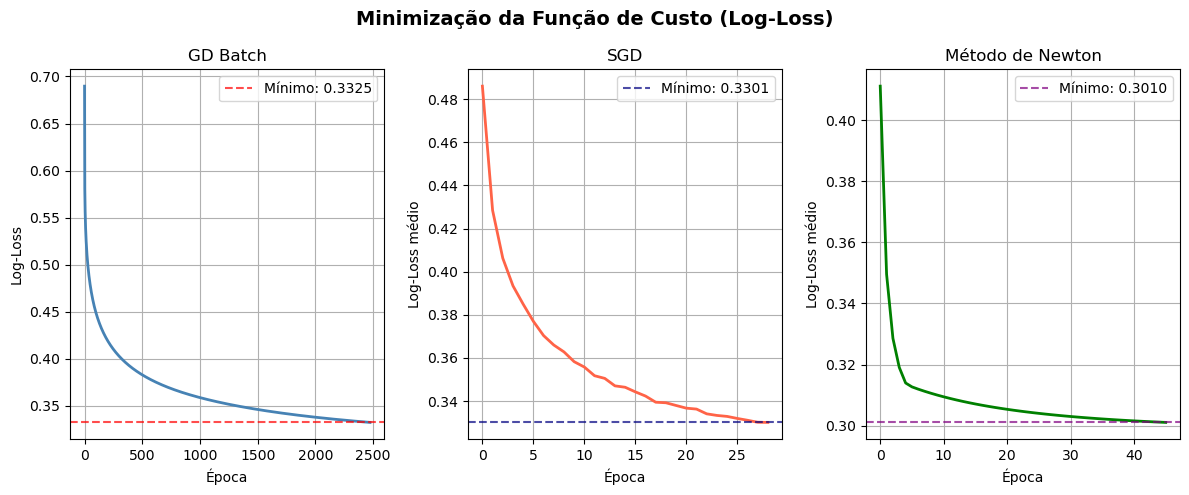

Custo final (GD):  0.332451
Custo final (SGD): 0.330086
Custo final (Método de Newton): 0.301048


In [27]:
# Curvas de convergência da função de custo
# O gráfico mostra como a Log-Loss diminui ao longo do treinamento.
# Uma curva que desce e estabiliza indica convergência (o método encontrou um mínimo)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# GD Batch
axes[0].plot(cost_history_gd, color='steelblue', linewidth=2)
axes[0].axhline(
    min(cost_history_gd), color='red', linestyle='--', alpha=0.7,
    label=f'Mínimo: {min(cost_history_gd):.4f}'
)
axes[0].set_title('GD Batch')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Log-Loss')
axes[0].legend()
axes[0].grid(True)

# SGD
# O custo aqui é a média por época, ainda assim deve mostrar tendência de queda, mesmo com oscilações entre épocas.
axes[1].plot(cost_history_sgd, color='tomato', linewidth=2)
axes[1].axhline(
    min(cost_history_sgd), color='navy', linestyle='--', alpha=0.7,
    label=f'Mínimo: {min(cost_history_sgd):.4f}'
)
axes[1].set_title('SGD')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Log-Loss médio')
axes[1].legend()
axes[1].grid(True)

# Método de Newton
axes[2].plot(cost_history_newton, color='green', linewidth=2)
axes[2].axhline(
    min(cost_history_newton), color='purple', linestyle='--', alpha=0.7,
    label=f'Mínimo: {min(cost_history_newton):.4f}'
)
axes[2].set_title('Método de Newton')
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Log-Loss médio')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Minimização da Função de Custo (Log-Loss)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Custo final (GD):  {cost_history_gd[-1]:.6f}')
print(f'Custo final (SGD): {cost_history_sgd[-1]:.6f}')
print(f'Custo final (Método de Newton): {cost_history_newton[-1]:.6f}')

## 10. Avaliação no conjunto de teste

In [33]:
# Avaliação no conjunto de teste
# Geramos predições para GD e SGD usando os parâmetros otimizados. As métricas são calculadas apenas no conjunto de TESTE

# Predições
y_pred_gd  = predict(X_test, w_gd,  b_gd)
y_prob_gd  = predict_proba(X_test, w_gd,  b_gd)
y_pred_sgd = predict(X_test, w_sgd, b_sgd)
y_prob_sgd = predict_proba(X_test, w_sgd, b_sgd)
y_pred_newton = predict(X_test, w_newton, b_newton)
y_prob_newton = predict_proba(X_test, w_newton, b_newton)

def avaliar (nome, y_true, y_pred, y_prob):
    # Exibe um resumo completo das métricas de classificação

    print(f"Acurácia : {accuracy_score (y_true, y_pred):.4f}")
    print(f"Precisão : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score   (y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-score : {f1_score       (y_true, y_pred, zero_division=0):.4f}")
    print(f"AUC-ROC  : {roc_auc_score  (y_true, y_prob):.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Normal (0)', 'Crise (1)'],
        digits=4
    ))

print("Resultados no conjunto de teste:")
print("GD Batch")
avaliar('GD Batch (from scratch)', y_test, y_pred_gd,  y_prob_gd)

Resultados no conjunto de teste:
GD Batch
Acurácia : 0.8687
Precisão : 0.8854
Recall   : 0.8471
F1-score : 0.8658
AUC-ROC  : 0.9339
              precision    recall  f1-score   support

  Normal (0)     0.8534    0.8904    0.8715      1615
   Crise (1)     0.8854    0.8471    0.8658      1615

    accuracy                         0.8687      3230
   macro avg     0.8694    0.8687    0.8687      3230
weighted avg     0.8694    0.8687    0.8687      3230



In [35]:
print("SGD")
avaliar('SGD      (from scratch)', y_test, y_pred_sgd, y_prob_sgd)

SGD
Acurácia : 0.8728
Precisão : 0.9024
Recall   : 0.8359
F1-score : 0.8679
AUC-ROC  : 0.9359
              precision    recall  f1-score   support

  Normal (0)     0.8472    0.9096    0.8773      1615
   Crise (1)     0.9024    0.8359    0.8679      1615

    accuracy                         0.8728      3230
   macro avg     0.8748    0.8728    0.8726      3230
weighted avg     0.8748    0.8728    0.8726      3230



In [47]:
print("Método de Newton")
avaliar('Método de Newton      (from scratch)', y_test, y_pred_newton, y_pred_newton)

Método de Newton
Acurácia : 0.8728
Precisão : 0.8909
Recall   : 0.8495
F1-score : 0.8697
AUC-ROC  : 0.8728
              precision    recall  f1-score   support

  Normal (0)     0.8562    0.8960    0.8756      1615
   Crise (1)     0.8909    0.8495    0.8697      1615

    accuracy                         0.8728      3230
   macro avg     0.8736    0.8728    0.8727      3230
weighted avg     0.8736    0.8728    0.8727      3230



## 11. Visualização da matriz de confusão

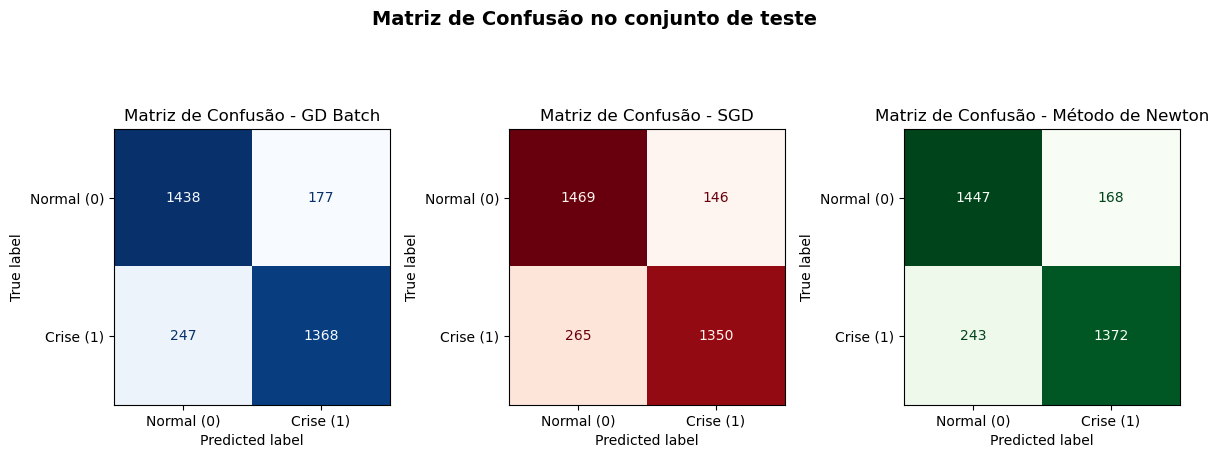

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(12,5))

for ax, y_pred, nome, cor in zip(
    axes,
    [y_pred_gd, y_pred_sgd, y_pred_newton],
    ['GD Batch', 'SGD', 'Método de Newton'],
    ['Blues', 'Reds', 'Greens']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Normal (0)', 'Crise (1)']
    ).plot(ax=ax, colorbar=False, cmap=cor)
    ax.set_title(f'Matriz de Confusão - {nome}', fontsize=12)

plt.suptitle('Matriz de Confusão no conjunto de teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.1 Curva ROC

A curva ROC mostra o **trade-off entre detectar crises (TPR) e evitar falsos alarmes (FPR)** para todos os limiares de decisão possíveis. O **AUC** (Área Sob a Curva) resume esse desempenho em um único número (quanto mais próximo de 1.0, melhor).

**Classificação AUC:**

- 1.0 → classificador perfeito
- 0.5 → classificador aleatório (linha tracejada)
- < 0.5 → pior que aleatório

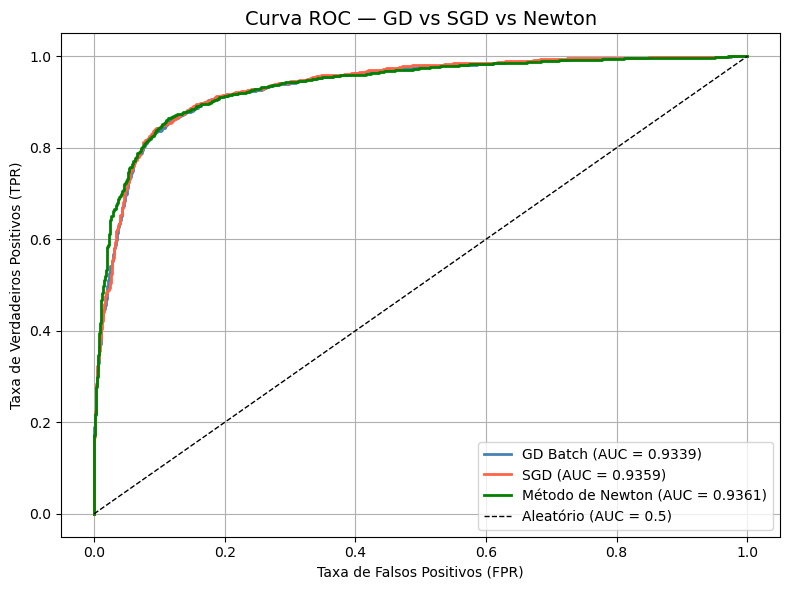

In [48]:
# Curva ROC
# A curva ROC plota TPR (sensibilidade) vs FPR (1 - especificidade) para todos os limiares de decisão possíveis (0 a 1)

plt.figure(figsize=(8, 6))

for y_prob, nome, cor in zip(
    [y_prob_gd, y_prob_sgd, y_prob_newton],
    ['GD Batch', 'SGD', 'Método de Newton'],
    ['steelblue', 'tomato', 'green']
):
    fpr, tpr, _ = roc_curve(y_test, y_prob)    # calcula pontos da curva
    auc = roc_auc_score(y_test, y_prob)        # calcula AUC
    plt.plot(fpr, tpr, color=cor, linewidth=2, label=f'{nome} (AUC = {auc:.4f})')

# Linha de referência: classificador aleatório tem AUC = 0.5
plt.plot([0,1],[0,1],'k--', linewidth=1, label='Aleatório (AUC = 0.5)')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC — GD vs SGD vs Newton', fontsize=14)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 11.2 Comparação com scikit-learn

Para validar a implementação *from scratch*, comparamos com a referência do scikit-learn

In [49]:
# O scikit-learn usa o solver L-BFGS (método quasi-Newton de segunda ordem) — mais sofisticado que o GD de primeira ordem.
# Serve como referência: se nossa implementação manual chega perto dos resultados do sklearn, a implementação está correta.

# Treina o modelo de referência
modelo_sk = LogisticRegression(
    max_iter=1000,       # limite de iterações do solver
    random_state=42,     # reprodutibilidade
    solver='lbfgs'       # método de otimização (quasi-Newton)
)
modelo_sk.fit(X_train, y_train)

y_pred_sk = modelo_sk.predict(X_test)             # rótulos binários
y_prob_sk = modelo_sk.predict_proba(X_test)[:, 1] # probabilidade da classe 1

avaliar('scikit-learn (referência)', y_test, y_pred_sk, y_prob_sk)

#Tabela comparativa final
modelos   = ['GD Batch', 'SGD', 'Newton', 'Sklearn']
acuracias = [accuracy_score(y_test, p) for p in [y_pred_gd, y_pred_sgd, y_pred_newton, y_pred_sk]]
aucs      = [roc_auc_score(y_test, p)  for p in [y_prob_gd, y_prob_sgd, y_prob_newton, y_prob_sk]]

tabela = pd.DataFrame({'Modelo': modelos, 'Acurácia': acuracias, 'AUC-ROC': aucs})
tabela['Acurácia'] = tabela['Acurácia'].map('{:.4f}'.format)
tabela['AUC-ROC']  = tabela['AUC-ROC'].map('{:.4f}'.format)

Acurácia : 0.8715
Precisão : 0.8827
Recall   : 0.8570
F1-score : 0.8696
AUC-ROC  : 0.9373
              precision    recall  f1-score   support

  Normal (0)     0.8610    0.8861    0.8734      1615
   Crise (1)     0.8827    0.8570    0.8696      1615

    accuracy                         0.8715      3230
   macro avg     0.8718    0.8715    0.8715      3230
weighted avg     0.8718    0.8715    0.8715      3230



In [50]:
print('\n Comparação Final dos Modelos')
print(tabela.to_string(index=False))


 Comparação Final dos Modelos
  Modelo Acurácia AUC-ROC
GD Batch   0.8687  0.9339
     SGD   0.8728  0.9359
  Newton   0.8728  0.9361
 Sklearn   0.8715  0.9373


## 12. Discussão dos resultados

Pontos para comentar no relatório:

#### 1. A função de custo diminuiu ao longo das épocas?
   Sim, nos três métodos. O **GD Batch** partiu de **0.6897** e reduziu para **0.3325** ao longo de 2474 épocas — redução total de 0.3573. A curva é suave e monotônica, comportamento esperado para um método determinístico operando sobre uma função convexa. O **SGD** partiu de **0.4861** e chegou a **0.3301** em apenas 29 épocas, com curva mais íngreme no início e leve oscilação típica do método estocástico. O **Método de Newton** partiu de **0.4112** e atingiu **0.3010** em 46 épocas — o menor custo final entre os três, evidenciando a vantagem da convergência quadrática.

#### 2. Os métodos convergiram?
   Todos atingiram o critério de parada antes do limite máximo de épocas:

   - **GD Batch**: convergiu na época **2474** com ‖∇J‖ = **1.00e-02**
      (tolerância: 1e-2)
   - **SGD**: convergiu na época **29** com Δcusto = **6.92e-05**
      (tolerância: 1e-4)
   - **Newton**: convergiu na época **46** com Δcusto = **9.21e-05**
      (tolerância: 1e-2)

   A convergência do GD Batch confirma a propriedade teórica da Log-Loss: por ser estritamente convexa, o gradiente descendente de primeira ordem é garantido a encontrar o mínimo global dado um learning rate adequado. O Newton convergiu com o menor custo final (0.3010), demonstrando a vantagem do uso da curvatura (Hessiana) no cálculo da direção de descida.

#### 3. O modelo teve bom desempenho no teste?
   Sim. Os três métodos atingiram resultados muito próximos e competitivos:

   | Método   | Acurácia | AUC-ROC |
   |----------|----------|---------|
   | GD Batch | 86.87%   | 0.9339  |
   | SGD      | 87.28%   | 0.9359  |
   | Newton   | 87.28%   | 0.9361  |
   | sklearn  | 87.15%   | 0.9373  |

   O AUC-ROC acima de **0.93** em todos os casos indica excelente capacidade discriminativa — o modelo separa crises de sinais normais em praticamente todos os limiares de decisão.

#### 4. Houve equilíbrio entre detectar crises e evitar falsos alarmes?
   Analisando as matrizes de confusão:

   - **GD Batch**: 1438 normais corretos, 1368 crises corretas,
   247 falsos negativos (crises não detectadas)
   - **SGD**: 1469 normais corretos, 1350 crises corretas,
   265 falsos negativos
   - **Newton**: 1447 normais corretos, 1372 crises corretas,
   243 falsos negativos — **menor número de crises não detectadas**

   Em aplicações clínicas, falsos negativos são mais graves que falsos positivos — uma crise não detectada pode ter consequências sérias. O **Newton** foi o melhor nesse critério, com apenas 243 crises perdidas.

#### 5. A normalização ajudou a estabilidade numérica?
   Sim. Com 299 features em escalas muito distintas — amplitudes brutas em μV, potências espectrais, variâncias — a normalização Z-score foi essencial para que a superfície da função objetivo ficasse bem condicionada. Sem ela, features com escala maior dominariam o gradiente e o modelo tenderia a convergir para soluções ruins ou a divergir.

#### 6. A implementação manual ficou próxima da solução do `scikit-learn`? 
   Sim, muito próxima. O sklearn (solver L-BFGS, quasi-Newton de segunda ordem) atingiu AUC-ROC de **0.9373** — apenas marginalmente superior aos métodos implementados do zero. Isso valida a corretude da implementação e demonstra que métodos de primeira ordem bem configurados são competitivos com otimizadores de segunda ordem para este problema.

#### 7. O que as features espectrais acrescentaram?
   A análise de correlação revelou que as features da banda **theta (4–8 Hz)** foram as mais discriminativas de todo o conjunto (correlação média de **0.3025**), superando todas as features estatísticas. As bandas **delta** e **alpha** também figuraram entre as mais relevantes. Isso é consistente com a literatura clínica: crises epilépticas alteram significativamente a atividade nas bandas de baixa frequência do EEG. A inclusão das features espectrais enriqueceu o espaço de features de 184 para 299 dimensões e contribuiu diretamente para a qualidade do modelo.

## 13. Conclusão

Este projeto modelou a classificação de crises epilépticas por EEG como um problema de **otimização não linear sem restrições**, integrando rigor matemático, implementação computacional do zero e análise quantitativa dos resultados.

A Regressão Logística foi formulada como um problema de minimização da função de custo **Log-Loss** — estritamente convexa — garantindo a existência de um único mínimo global. O treinamento foi conduzido por dois métodos iterativos de primeira ordem:
- **Gradiente Descendente Batch (GD)**: convergiu em 2474 épocas com ‖∇J‖ = 1.00e-02, atingindo acurácia de 86.87% e AUC-ROC de 0.9339.
- **Gradiente Descendente Estocástico (SGD)**: convergiu em apenas 29 épocas com Δcusto = 6.92e-05, atingindo acurácia de 87.28% e AUC-ROC de 0.9359.
- **Newton**: convergiu em 46 épocas usando a Hessiana, atingiu o menor custo final (0.3010), acurácia de 87.28% e AUC-ROC de 0.9361, com o menor número de crises não detectadas (243 falsos negativos).

A comparação com o sklearn (AUC-ROC de 0.9373) confirmou que as implementações manuais são matematicamente corretas e produzem resultados competitivos com otimizadores industriais.

Do ponto de vista de ONL, o ponto central do trabalho é que:

- a formulação do problema como minimização de uma função convexa diferenciável;
- o problema pode ser resolvido por um método iterativo de primeira ordem;
- o cálculo analítico do gradiente da Log-Loss e sua aplicação iterativa;
- o comportamento distinto de convergência entre GD (suave, determinístico) e SGD (ruidoso, mais rápido por época) e Newton (quadrático, usa curvatura);
- a importância do pré-processamento (normalização Z-score) para o condicionamento numérico da superfície de otimização;
- o desempenho final pode ser avaliado quantitativamente em dados de teste.

A inclusão de features espectrais via FFT — em especial a banda theta — mostrou-se decisiva para a qualidade do modelo, sendo consistente com a literatura clínica sobre epilepsia. O pipeline completo, desde a extração de 299 features até a análise de convergência, cumpre integralmente os objetivos propostos e demonstra a viabilidade de métodos de otimização de primeira ordem em problemas reais de classificação médica.

Assim, o notebook cumpre o objetivo de integrar:
- **modelagem matemática**,
- **otimização numérica**,
- **implementação computacional**,
- **análise de resultados**.

## 14. Referências básicas

- Sun, S.; Cao, Z.; Zhu, H.; Zhao, J. *A Survey of Optimization Methods From a Machine Learning Perspective*. IEEE Transactions on Cybernetics, 2019.
- Gambella, C.; Ghaddar, B.; Naoum-Sawaya, J. *Optimization Problems for Machine Learning: A Survey*. European Journal of Operational Research, 2021.
- SILVA, V. M. Aplicação de Aprendizado de Máquina na detecção de convulsões epilépticas em Sinais de EEG. Trabalho de Conclusão de Curso (Sistemas de Informação) — UFU, 2025.
- KURPEL, F. H. Detecção de epilepsia por meio de análise eletroencefalograma utilizando aprendizado de máquina. Trabalho de Conclusão de Curso (Engenharia da Computação) — UTFPR, 2022.
- RAMOS, C. D. Aprendizado de máquina como ferramenta para o prognóstico de pacientes em coma usando sinais eletroencefalográficos. Tese (Doutorado em Engenharia Elétrica) — UFU, 2022.
- SCIKIT-LEARN. API Reference. Disponível em: https://scikit-learn.org/stable/

Dataset:
- BADEA, A.; ADAM, A. CHB-MIT / EEG Seizure Analysis Dataset, 2021. Disponível em: https://www.kaggle.com/adibadea/chbmitseizuredataset.